# Main — Combined Tip 1 + Tip 2 Features

Toggle `USE_TIP1` / `USE_TIP2` to include or exclude each feature set.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import lightgbm as lgbm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

from all_features import build_features, apply_target_encoding

### Config — toggle feature sets here

In [ ]:
USE_TARGET_ENCODING = True   # Tip 5 ALLOC_ENC — computed per fold to avoid leakage

### Load data

In [30]:
X_train = pd.read_csv('../data/X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('../data/X_test.csv',  index_col='ROW_ID')
y_train = pd.read_csv('../data/y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('../submission/sample_submission.csv', index_col='ROW_ID')

RET_cols = [f'RET_{i}'           for i in range(1, 21)]
VOL_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

### Feature engineering

#### Benchmark features (always included)

# Benchmark features are now computed inside build_features() — no separate step needed.

#### All tips (1–5) via all_features.py

In [ ]:
X_train, features = build_features(X_train, RET_cols, VOL_cols)
X_test,  _        = build_features(X_test,  RET_cols, VOL_cols)

# ALLOC_ENC is added per fold — include it in the feature list now as a placeholder
if USE_TARGET_ENCODING:
    features = features + ['ALLOC_ENC']

print(f"Total features: {len(features)}")

### LightGBM — 8-fold cross-validation on dates

In [ ]:
lgbm_params = {
    "objective":     "mse",
    "metric":        "mse",
    "num_threads":   50,
    "seed":          42,
    "verbosity":     -1,
    "learning_rate": 1e-2,
    "max_depth":     3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
scores, models = [], []

splits = KFold(n_splits=8, shuffle=True, random_state=0).split(train_dates)

for fold, (tr_idx, val_idx) in enumerate(splits):
    tr_mask  = X_train['TS'].isin(train_dates[tr_idx])
    val_mask = X_train['TS'].isin(train_dates[val_idx])

    y_tr  = y_train.loc[tr_mask,  'target']
    y_val = y_train.loc[val_mask, 'target']

    if USE_TARGET_ENCODING:
        X_tr  = apply_target_encoding(X_train.loc[tr_mask], y_tr, X_train.loc[tr_mask])[features].fillna(0)
        X_val = apply_target_encoding(X_train.loc[tr_mask], y_tr, X_train.loc[val_mask])[features].fillna(0)
    else:
        X_tr  = X_train.loc[tr_mask,  features].fillna(0)
        X_val = X_train.loc[val_mask, features].fillna(0)

    model = lgbm.train(lgbm_params,
                       lgbm.Dataset(X_tr, label=y_tr.values),
                       num_boost_round=NUM_BOOST_ROUND)

    preds = model.predict(X_val.values, num_threads=lgbm_params['num_threads'])
    acc   = accuracy_score((y_val > 0).astype(int), (preds > 0).astype(int))

    models.append(model)
    scores.append(acc)
    print(f"Fold {fold+1} — Accuracy: {acc*100:.2f}%")

mean = np.mean(scores) * 100
std  = np.std(scores)  * 100
print(f"\nAccuracy: {mean:.2f}% ± {std:.2f}%  [{mean-std:.2f} ; {mean+std:.2f}]")

### Feature importance (top 30 by gain)

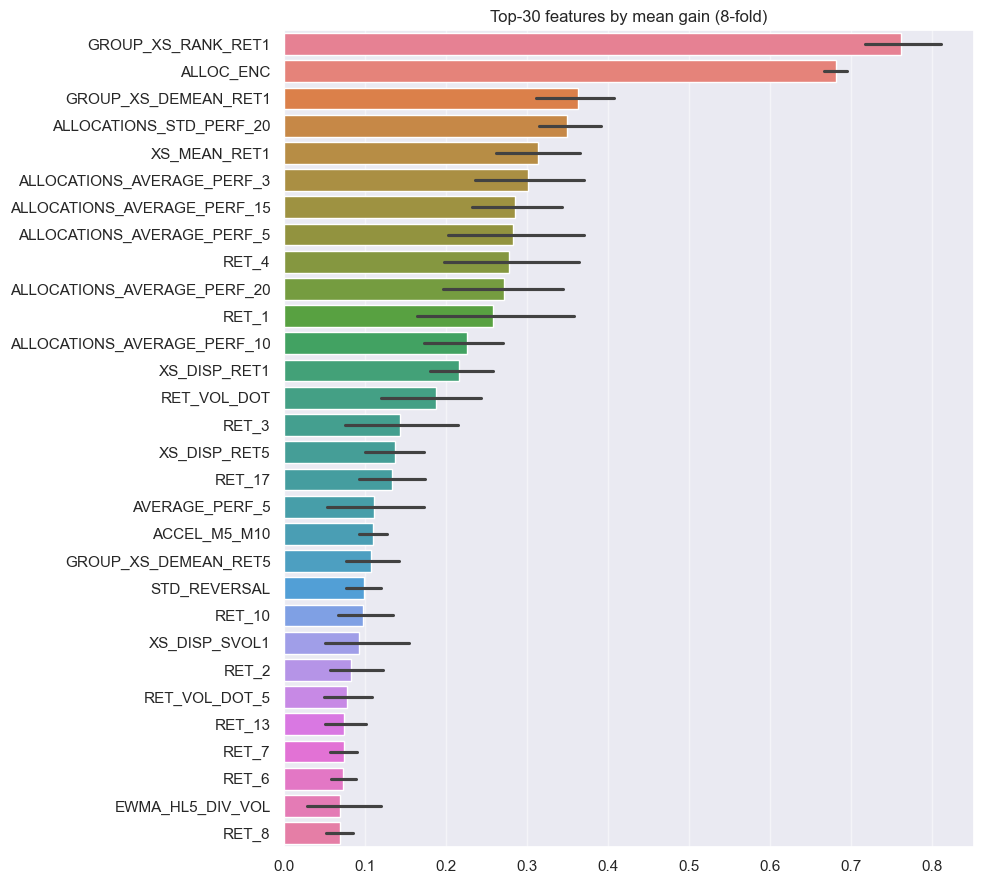

In [34]:
importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models],
    columns=features
)
top30 = importances.mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(10, 9))
sns.barplot(data=importances[top30], orient='h',
            order=importances[top30].mean().sort_values(ascending=False).index)
plt.title("Top-30 features by mean gain (8-fold)")
plt.tight_layout()
plt.show()

### Final model + submission

In [ ]:
if USE_TARGET_ENCODING:
    X_train_final = apply_target_encoding(X_train, y_train['target'], X_train)
    X_test_final  = apply_target_encoding(X_train, y_train['target'], X_test)
else:
    X_train_final = X_train
    X_test_final  = X_test

final_model = lgbm.train(
    lgbm_params,
    lgbm.Dataset(X_train_final[features].fillna(0), label=y_train['target'].values),
    num_boost_round=NUM_BOOST_ROUND
)

test_preds = final_model.predict(X_test_final[features].fillna(0).values)
submission = pd.DataFrame(
    (test_preds > 0).astype(int),
    index=sample_submission.index,
    columns=['TARGET']
)
submission.to_csv('preds_all_tips.csv')
print("Saved preds_all_tips.csv")
submission['TARGET'].value_counts()